![hslu_logo.png](img/hslu_logo.png)

## Week 3

<hr style="border:1px solid black">

# Excercise: Introduction to Convolutions
---
---
Convolutions are used in image processing to enhance certain features. Typical applications are low- or high-pass filter. Here we are in particular interested in high-pass filter in order to enhance texture. While the standard application of convolutions in image processing is on single channel images (b/w) we will here extend this concept to multi-channel images. Therefore in cell [2] either the (Fashion-)MNIST or the CIFAR10 images can be chosen as examples for single or multi channel images respectively.

### Import necessary packages

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from utils import read_data_orig, plot_img, plot_tiles

#### Download dataset (MNIST, FashionMNIST or CIFAR10)

In [42]:
#data is saved in storage_path (use same path for different SW)
#MNIST, FashionMNIST or CIFAR10
# training_data, test_data, labels_map = read_data_orig('FashionMNIST', storage_path='../SW01/data') 
training_data, test_data, labels_map = read_data_orig('CIFAR10', storage_path='../SW01/data') 


if len(training_data.data.shape) == 3:
    training_data.data = training_data.data.unsqueeze(1)
    test_data.data = test_data.data.unsqueeze(1)

num_images_planes = training_data.data.shape[1]


print('converted data types')
print(training_data.data.shape)

Files already downloaded and verified
Files already downloaded and verified
converted data types
torch.Size([50000, 3, 32, 32])


In [43]:
labels_map

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

#### plot sample images

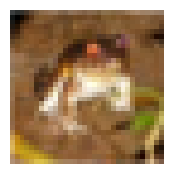

In [44]:
plot_img(torch.movedim(training_data.data[0], [0],[2]), figure_size = [2,2])

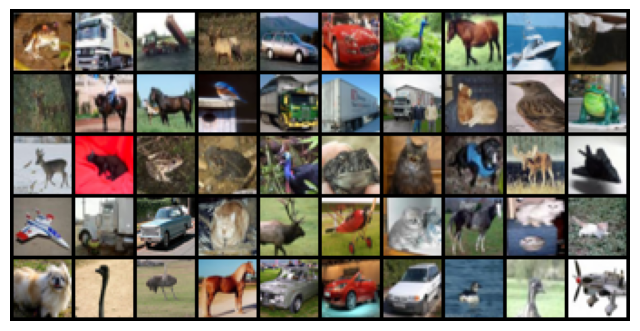

In [45]:
#plot categories mixed
plot_tiles(training_data.data, 10,5)

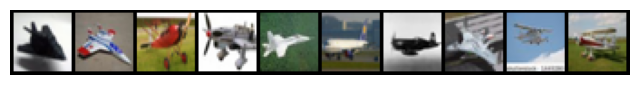

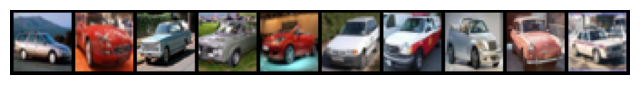

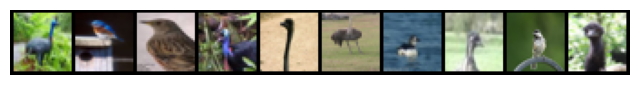

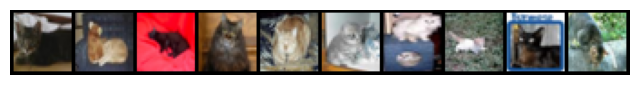

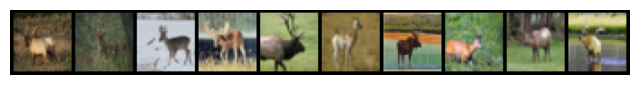

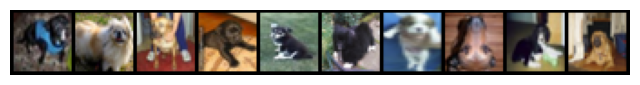

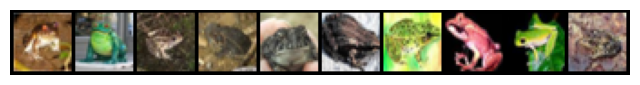

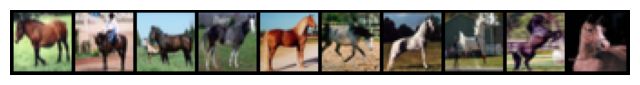

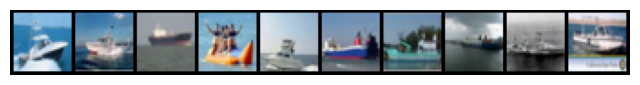

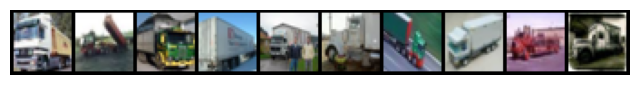

In [46]:
#plot only certain categorie
for label in range(10):
    plot_tiles(training_data.data[training_data.targets == label], 10,1)

### Apply convolution

Choose a given category of images and observe the result of the convolution. Note that the return value for the multi-channel input is also of single channel type.

airplane
kernel type:
tensor([[[ 0.,  1.,  0.],
         [ 1., -4.,  1.],
         [ 0.,  1.,  0.]]])


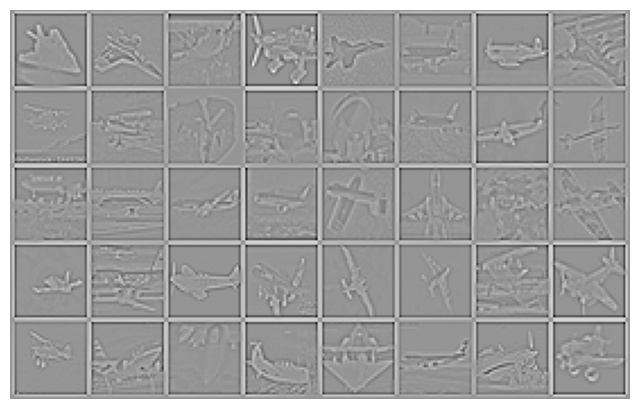


source image shape:  [3, 172, 274]
kernel shape:  [1, 3, 3, 3]
result image shape:  [1, 172, 274]


In [51]:
#choose a given class 0..9
category  = 0

x_sel = training_data.data[training_data.targets == category]
img_grid = torchvision.utils.make_grid(x_sel[:40])
#make_grid turns 1D image into 3D :-/
if x_sel.shape[1] == 1:
    img_grid = img_grid[:1]
    
print(labels_map[category])

#here you can define the kernel type
kernel_tpye = 2

if kernel_tpye == 0:
    #edge detection in x-direction
    kernel_1D = torch.tensor([[[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]]], dtype=torch.float32)
elif kernel_tpye == 1:
    #edge detection in y-direction
    kernel_1D = torch.tensor([[[-1, -2, -1],[0, 0, 0],[1, 2, 1]]], dtype=torch.float32)
elif kernel_tpye == 2:
    #laplace filter for edge detection (2nd derivative)
    kernel_1D = torch.tensor([[[0, 1, 0],[1, -4, 1],[0, 1, 0]]], dtype=torch.float32)

print('kernel type:')
print(kernel_1D)

#for multi-channels we simply stack the 1D kernel
kernel_3D = torch.cat([kernel_1D,kernel_1D,kernel_1D],axis=0)

if img_grid.shape[0] == 1:
    kernel = kernel_1D.unsqueeze(0)
else:
    kernel = kernel_3D.unsqueeze(0)

conv_img = torch.nn.functional.conv2d(img_grid.to(torch.float32), kernel, padding="same")

#scale image to [0,1] for proper output
plot_img(torch.movedim(conv_img, [0],[2]), figure_size = [8,8])

print('\nsource image shape: ', list(img_grid.shape))
print('kernel shape: ', list(kernel.shape))
print('result image shape: ', list(conv_img.shape))


In [52]:
# --> 2 pixel "verloren?"
# Filter: 3x3 gross, problem: Am Rand fehlen Pixel, daher 2 Pixel verloren
# Pytorch nimmt als default "no padding" --> Das heisst, er hört auf sobald der Filter am rand "anstösst" 
# Dadurch verliert er ein Pixel an jeder Seite
# Das "wollen wir nicht"
# Lösung: Padding festlegen --> padding = 1, bzw "same"
# Nun ist result shape gleich input shape
# 
# Padding mode: "zeros" kann zu artefakten führen, da er die Ränder mit 0 füllt. Bei diesen Bildern macht dieser aber keinen unterschied. 
# Typischerweise wird "reflect" oder replicate verwendet und artifakte zu vermeiden. 
# 
# CIFAR10 Bilder (rgb Bilder), zusätzlicher Kanel weil wir es 3x duplizieren
# Jedes dieser 3x3 wird über den jeweiligen Farbkanal geschoben. 
# Ausgabe bleibt ein Kanal

In [ ]:
kernel_1D.shape